In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#from scipy.interpolate import interp1d

In [19]:
#Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})


--- Measurement Summary ---
Measurement  Max Stroke [µm]
       75 V       659.060000
       60 V       578.900190
       40 V       421.113000
       20 V       189.706000
       2 V         12.781676


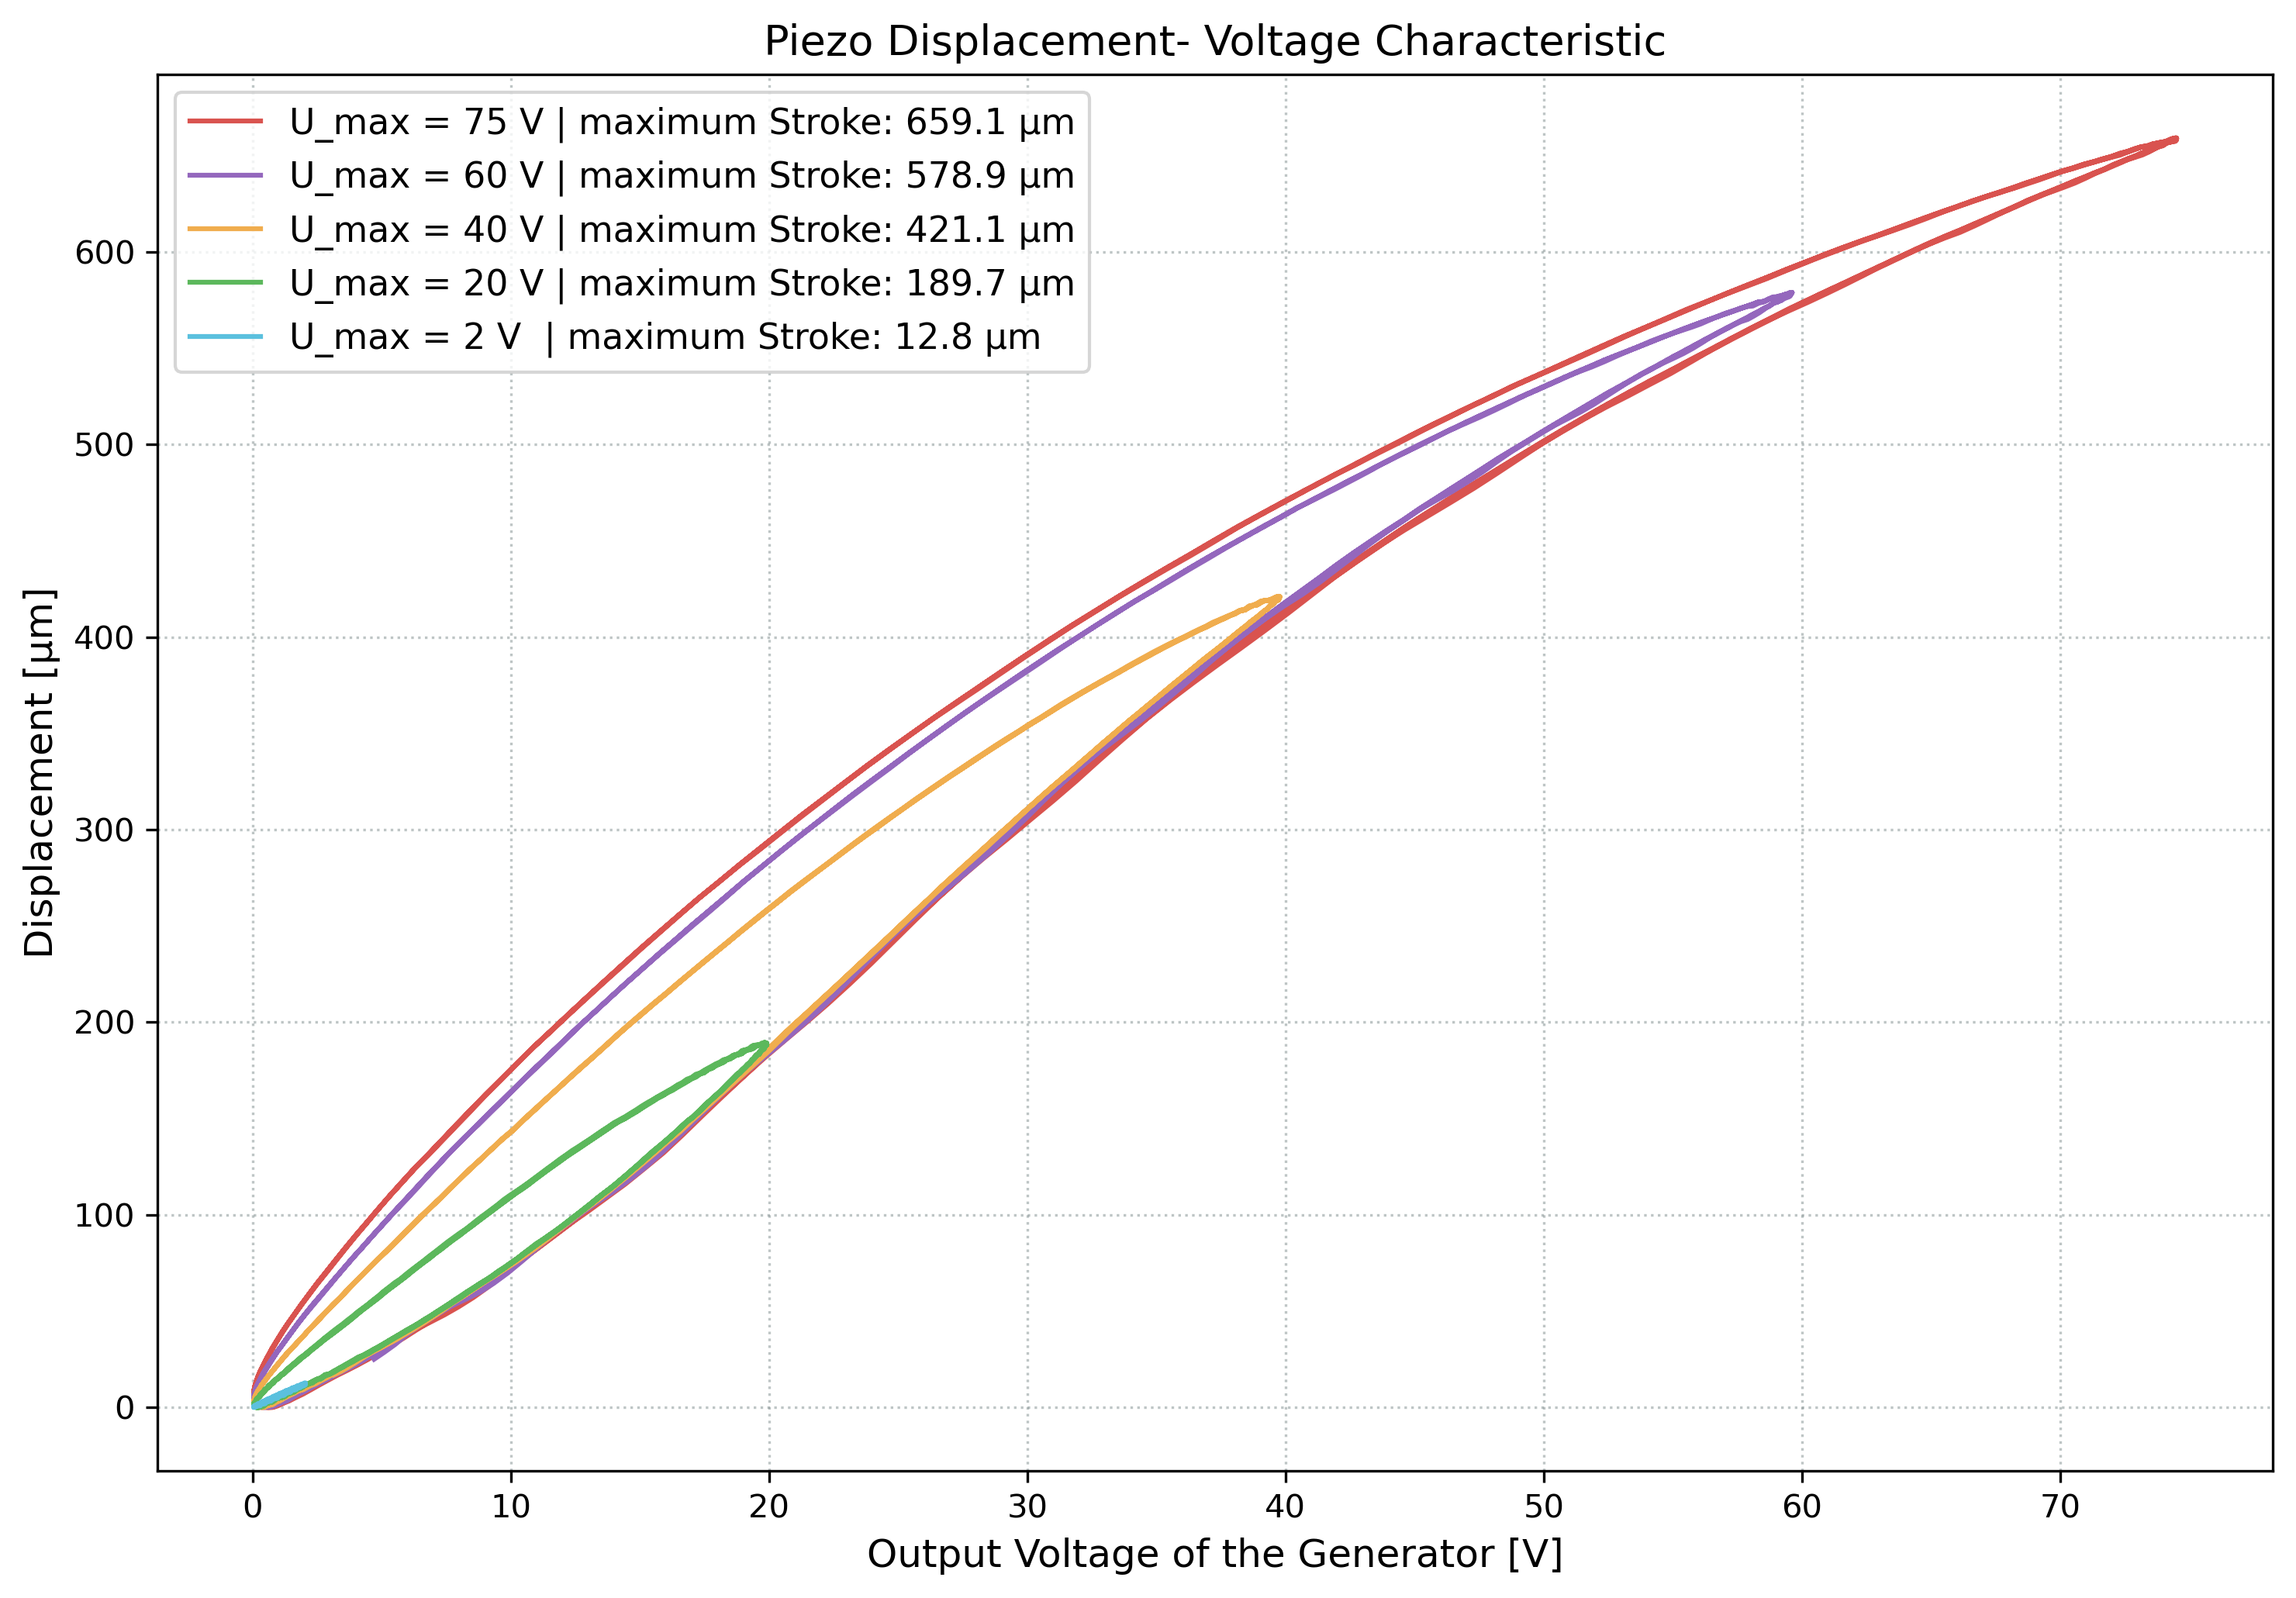

In [22]:
#richtig ohne hysterese angabe
# Basisverzeichnis für die Messdateien
base_path = "/Users/trinity/Desktop/bachelor.thesis/measurements/piezo/"

# Konfiguration der Messungen auf Englisch (ohne Hysterese in der Legende)
measurements = [
    {
        "name": "75 V", #(3.75 V)
        "weg": "3,75weg.txt",
        "spannung": "3,75spannung.txt",
        "color": "#D9534F",
    },
    {
        "name": "60 V", # (3 V)
        "weg": "3weg.txt",
        "spannung": "3spannung.txt",
        "color": "#9467BD",
    },
    {
        "name": "40 V", # (2 V)
        "weg": "2weg.txt",
        "spannung": "2spannung.txt",
        "color": "#F0AD4E",
    },
    {
        "name": "20 V", #1.0 V)
        "weg": "1weg.txt",
        "spannung": "1spannung.txt",
        "color": "#5CB85C",
    },
    {
        "name": "2 V ", #(0.1 V)
        "weg": "0,1weg.txt",
        "spannung": "0,1spannung.txt",
        "color": "#5BC0DE",
    },
]

results = []
plot_data = []

# Einlesen und Auswerten aller Messungen
for m in measurements:
  try:
    file_w = base_path + m["weg"]
    file_s = base_path + m["spannung"]

    df_w = pd.read_csv(
        file_w, sep="\t", skiprows=5, header=None, names=["Zeit", "Weg"]
    )
    df_s = pd.read_csv(
        file_s, sep="\t", skiprows=5, header=None, names=["Zeit", "Spannung"]
    )

    df_w = df_w.apply(pd.to_numeric, errors="coerce")
    df_s = df_s.apply(pd.to_numeric, errors="coerce")
    df_m = pd.merge(df_w, df_s, on="Zeit")

    spannung = df_m["Spannung"].values * 10.0
    weg_raw = df_m["Weg"].values
    weg = weg_raw - np.min(weg_raw)
    max_weg = np.max(weg)
    weg_mum = 1000 * weg

    results.append(
        {
            "Measurement": m["name"],
            "Max Stroke [µm]": max_weg * 1000,
        }
    )
    plot_data.append(
        {
            "name": m["name"],
            "weg_mum": weg_mum,
            "spannung": spannung,
            "color": m["color"],
            "max_hub": max_weg * 1000,
        }
    )

  except FileNotFoundError:
    print(f"File for {m['name']} not found, skipped.")

# Ergebnisse in der Konsole ausgeben
df_res = pd.DataFrame(results)
print("\n--- Measurement Summary ---")
print(df_res.to_string(index=False))

# ---------------------------------------------------------------------------
# Plotten aller Messungen in ein einziges Diagramm (komplett auf Englisch)
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

for data in plot_data:
  plt.plot(
    data["spannung"],
      data["weg_mum"],
      color=data["color"],
      label=f"U_max = {data['name']} | maximum Stroke: {data['max_hub']:.1f} µm",
  )

# Diagramm-Beschriftungen und Layout auf Englisch
plt.title("Piezo Displacement- Voltage Characteristic")
plt.ylabel("Displacement [µm]")
plt.xlabel("Output Voltage of the Generator [V]")
plt.legend(loc="upper left")
plt.tight_layout()

# Optional: Diagramm direkt als Bild abspeichern
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/piezo/piezo_characteristic.pdf")

# Diagramm anzeigen
plt.show()

In [ ]:
#mayself
'''
np.max(data["spannung"])
x wert
np.arg
data["weg_mum"],

for a in range(len(data["spannung"])):

    target_voltage = data["spannung"][a]

    max_idx = np.argmax(data["spannung"])
    s_up, w_up = data["spannung"][:max_idx], data["weg_mum"][:max_idx]
    s_down, w_down = data["spannung"][max_idx:], data["weg_mum"][max_idx:]

    idx_up = np.argmin(np.abs(s_up - target_voltage))
    idx_down = np.argmin(np.abs(s_down - target_voltage))

    weg_up = w_up[idx_up]
    weg_down = w_down[idx_down]

    real_voltage_up = s_up[idx_up]    # Falls 30V nicht exakt im Messraster liegt
    real_voltage_down = s_down[idx_down]

    difference = weg_up - weg_down
    diff_vec=[]
    diff_vec.append(difference)

max_diff = np.max(diff_vec)
print(f"Maximum difference in displacement at the same voltage=hytserese: {max_diff:.2f} µm")

'''